# Modelling Kategorisasi Otomatis — MLP (TensorFlow) & IndoBERT

Notebook ini berisi pipeline pembuatan model kategorisasi teks menggunakan:
1. **Feature Extraction:** IndoBERT (Hugging Face / PyTorch)
2. **Classifier:** MLP Functional API (TensorFlow / Keras)

**Fitur Lanjutan:** Custom Layer (Residual Block), Custom Loss (Focal Loss), Custom Callback, `tf.GradientTape`, dan TensorBoard.
Artifacts yang dihasilkan siap untuk di-deploy ke backend.

## Cell 2: Install Dependencies

In [1]:
# !pip install transformers torch scikit-learn openpyxl nltk tensorflow --quiet


In [2]:
!pip install sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.8 MB/s eta 0:00:00


## Cell 1 — Import Libraries

In [3]:
import os, re, json, pickle, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
from transformers import AutoTokenizer, AutoModel

nltk.download('punkt',     quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")


TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Load Dataset dari GitHub

In [4]:
# API_URL = (
#     "https://api.github.com/repos/maxrumbo/CapstoneProject_CC26-PSU329"
#     "/contents/data-scientist/kategorisasi/Clean Dataset Pengeluaran/hasil_pengeluaran_newest?ref=development"
# )

# response  = requests.get(API_URL)
# csv_files = [f for f in response.json() if f["name"].endswith(".csv")]
# print(f"Total CSV: {len(csv_files)}")

# df_tmp = pd.read_csv(StringIO(requests.get(csv_files[0]["download_url"]).text))

# FILE_CONFIG = {
#     "Entertainment" : "entertainment",
#     "Langganan"     : "langganan",
#     "Kesehatan"     : "kesehatan",
#     "Konsumsi"      : "konsumsi",
#     "Transport"     : "transport",
#     "Tagihan"       : "tagihan",
# }

# df_tmp["label"] = df_tmp["label"].map(FILE_CONFIG)
# df_all = df_tmp[["clean_text", "label"]].rename(columns={"clean_text": "teks_bersih"})
# df_all = df_all[~df_all["teks_bersih"].isin(["nan", "None", ""])].dropna().reset_index(drop=True)

# print(f"\n✅ Total: {len(df_all):,} baris")
# print(df_all["label"].value_counts().to_string())

In [5]:
## Cell 2 — Load Dataset dari GitHub (Single CSV)

import pandas as pd
from io import StringIO
import requests

CSV_URL = (
    "https://raw.githubusercontent.com/maxrumbo/CapstoneProject_CC26-PSU329"
    "/refs/heads/development/data-scientist/kategorisasi/"
    "Clean%20Dataset%20Pengeluaran/hasil_preprocessing_newest.csv"
)

# Cek koneksi dan status response
response = requests.get(CSV_URL)
print(f"Status Code: {response.status_code}")

# Hentikan jika URL tidak valid
response.raise_for_status()

# Baca CSV dari response
df_all = pd.read_csv(StringIO(response.text))
print(f"Kolom tersedia: {df_all.columns.tolist()}")

# Gunakan kolom clean_text dan label
df_all = df_all[["clean_text", "label"]].rename(columns={"clean_text": "teks_bersih"})

# Bersihkan baris tidak valid
df_all = df_all[~df_all["teks_bersih"].isin(["nan", "None", ""])].dropna().reset_index(drop=True)

# Drop baris yang labelnya adalah string "label" (header duplikat)
df_all = df_all[df_all["label"] != "label"].reset_index(drop=True)

print(f"✅ Total: {len(df_all):,} baris")
print(df_all["label"].value_counts().to_string())
df_all.head(3)

Status Code: 200
Kolom tersedia: ['Nama Produk', 'label', 'text_cleaned', 'text_stopwords_removed', 'clean_text', 'token_awal', 'token_akhir', 'reduksi', 'persen_%']
✅ Total: 61,075 baris
label
Entertainment    40381
Konsumsi         12378
Kesehatan         3141
Langganan         2132
Tagihan           1985
Transport         1058


,teks_bersih,label
0,jeans naomi soft jeans streectmelar,Entertainment
1,denim celana jeans celana jeans jeans korean s...,Entertainment
2,celana jeans skinny stretch jins abu pensil sl...,Entertainment


In [6]:
# df_all where label = "label"
df_all[df_all["label"] == "label"].head(3)

,teks_bersih,label


In [7]:
# drop where label = label
df_all = df_all[df_all["label"] != "label"]
df_all[df_all["label"] == "label"].head(3)

,teks_bersih,label


## Cell 3 — Text Preprocessing

In [8]:
# Cell 3 — Text Preprocessing (Cleaning Data style)
import re
import string
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('stopwords', quiet=True)

# Stemmer Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Stopwords Indonesia dari NLTK
stop_words = set(stopwords.words('indonesian'))

# Custom stopwords (dari notebook cleaning)
custom_stopwords = {
    "promo", "promosi", "sale", "diskon", "discount", "obral",
    "cuci", "gudang", "clearance", "flash", "live", "hot", "deal", "hemat", "murah meriah",
    "murah", "termurah", "terjangkau", "harga",
    "cod", "bayar", "ditempat", "gratis", "free",
    "ongkir", "ongkos", "kirim", "cashback", "voucher",
    "terbaru", "terlaris", "terpercaya", "terpopuler",
    "best", "seller", "bestseller", "hits", "viral",
    "premium", "super", "ultra", "spesial", "eksklusif",
    "original", "ori", "asli", "import", "branded",
    "recommended", "rekomendasi", "pilihan", "unggulan",
    "ready", "stock", "stok", "available", "tersedia",
    "new", "arrival", "limited", "edition",
    "fashion", "distro", "brand", "koleksi",
    "kualitas", "berkualitas", "garansi", "resmi",
    "buruan", "segera", "borong", "grosir", "ecer",
    "bisa", "dapat",
    "gr", "gram", "kg", "liter", "ml", "cm", "mm", "meter",
    "pcs", "pc", "buah", "butir", "biji", "lembar", "helai",
    "pasang", "set", "lusin", "kodi", "roll", "dus", "karton",
    "netto", "neto", "bruto", "gross", "net",
    "xl", "xxl", "s", "m", "l", "xs", "xxs",
    "varian", "variant", "variasi", "warna", "ukuran", "size", "motif", "tipe", "type",
    "paket", "packet", "pack", "packing", "kemas", "kemasan",
    "box", "kotak", "botol", "sachet", "pouch",
    "porsi", "menu", "reguler", "regular", "large", "small", "medium", "mini", "jumbo",
    "jual", "dijual", "jualin", "jualan", "toko", "shop", "store", "lapak", "online",
    "reseller", "dropship",
    "pria", "wanita", "cowok", "cewek", "laki", "perempuan",
    "dewasa", "anak", "remaja", "bayi", "balita", "lansia",
    "dll", "dkk", "dsb", "dst", "etc",
    "semua", "seluruh", "berbagai", "beragam", "lengkap", "komplit",
    "nota", "kode", "link", "maaf", "error", "etalase",
    "saya", "kami", "kamu", "anda", "mereka", "kalian", "aku", "gue", "lo",
    "pcs", "ml", "gr", "kg", "ltr", "btl", "bks", "pkt"
}

all_stopwords = stop_words.union(custom_stopwords)

# Pastikan kata domain penting tidak ikut kehapus
domain_words = {"solar", "transport", "langganan", "tagihan", "kesehatan", "konsumsi", "entertainment"}
all_stopwords -= domain_words


def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def remove_stopwords(text: str) -> str:
    words = text.split()
    filtered = [w for w in words if w not in all_stopwords and len(w) > 1]
    return " ".join(filtered)


def stemming(text: str) -> str:
    return stemmer.stem(text)


def preprocess(text: str) -> str:
    """
    Pipeline: clean → remove stopwords → stemming
    Catatan: stemming dimatikan untuk input IndoBERT
    agar representasi subword tetap natural.
    """
    text = clean_text(text)
    text = remove_stopwords(text)
    # text = stemming(text)
    return text

print("✅ Fungsi preprocessing siap digunakan")

✅ Fungsi preprocessing siap digunakan


## Cell 4 — Label Encoding & Train/Test Split

In [9]:
le = LabelEncoder()
df_all["label_id"] = le.fit_transform(df_all["label"])
N_CLASSES = len(le.classes_)

print("Mapping label:")
for i, name in enumerate(le.classes_):
    print(f"  {i} → {name}")

X = df_all["teks_bersih"].tolist()
y = df_all["label_id"].tolist()

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"\nTrain : {len(X_train_txt):,} | Test : {len(X_test_txt):,}")


Mapping label:
  0 → Entertainment
  1 → Kesehatan
  2 → Konsumsi
  3 → Langganan
  4 → Tagihan
  5 → Transport

Train : 48,860 | Test : 12,215


---
## BAGIAN 1 — MLP dengan IndoBERT Embeddings (TensorFlow)

Pipeline ekstraksi fitur menggunakan **IndoBERT** (PyTorch) lalu diklasifikasikan  
dengan **MLP berbasis TensorFlow**, diimplementasikan dalam dua cara:
- **Pipeline A** → Functional API
- **Pipeline B** → Model Subclassing


## Cell 5 — IndoBERT Feature Extraction

In [10]:
MODEL_NAME = "indobenchmark/indobert-base-p1"
print(f"Loading IndoBERT: {MODEL_NAME} (~440 MB)...")

tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model     = AutoModel.from_pretrained(MODEL_NAME)

DEVICE_BERT = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model  = bert_model.to(DEVICE_BERT)
bert_model.eval()

print(f"✅ IndoBERT siap di: {DEVICE_BERT}")

def extract_bert_features(texts, batch_size=32, max_length=64):
    """Mean-pooling IndoBERT → numpy [N, 768]."""
    all_embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch   = texts[i : i + batch_size]
            encoded = tokenizer_bert(
                batch, padding=True, truncation=True,
                max_length=max_length, return_tensors="pt"
            )
            encoded = {k: v.to(DEVICE_BERT) for k, v in encoded.items()}
            outputs = bert_model(**encoded)

            mask     = encoded["attention_mask"].unsqueeze(-1).float()
            sum_emb  = (outputs.last_hidden_state * mask).sum(1)
            mean_emb = sum_emb / mask.sum(1)
            all_embeddings.append(mean_emb.cpu().numpy())

            done = min(i + batch_size, len(texts))
            if done % 1000 == 0 or done == len(texts):
                print(f"  [{done}/{len(texts)}]")

    return np.vstack(all_embeddings)

print("\nEkstrak fitur TRAIN...")
X_train_emb = extract_bert_features(X_train_txt)
print("Ekstrak fitur TEST...")
X_test_emb  = extract_bert_features(X_test_txt)

print(f"\n✅ X_train_emb: {X_train_emb.shape}")
print(f"   X_test_emb : {X_test_emb.shape}")


Loading IndoBERT: indobenchmark/indobert-base-p1 (~440 MB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ IndoBERT siap di: cuda

Ekstrak fitur TRAIN...
  [4000/48860]
  [8000/48860]
  [12000/48860]
  [16000/48860]
  [20000/48860]
  [24000/48860]
  [28000/48860]
  [32000/48860]
  [36000/48860]
  [40000/48860]
  [44000/48860]
  [48000/48860]
  [48860/48860]
Ekstrak fitur TEST...
  [4000/12215]
  [8000/12215]
  [12000/12215]
  [12215/12215]

✅ X_train_emb: (48860, 768)
   X_test_emb : (12215, 768)


## Cell 6 — Custom Components

Tiga komponen kustom yang digunakan bersama oleh Pipeline A & B:
- **`ResidualBlock`** — Custom Layer dengan skip connection
- **`FocalLoss`** — Custom Loss untuk menangani class imbalance
- **`MetricsLogger`** — Custom Callback untuk logging per epoch


In [11]:
# ── 1. CUSTOM LAYER: ResidualBlock ─────────────────────────────────────────
class ResidualBlock(layers.Layer):
    """
    Dense layer dengan skip connection (residual).
    Input dan output berdimensi sama (units).
    """
    def __init__(self, units, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.dense1   = layers.Dense(units, activation="relu")
        self.dense2   = layers.Dense(units)
        self.bn       = layers.BatchNormalization()
        self.dropout  = layers.Dropout(dropout_rate)
        self.add      = layers.Add()
        self.relu     = layers.Activation("relu")

    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.dropout(x, training=training)
        x = self.dense2(x)
        x = self.bn(x, training=training)
        x = self.add([x, inputs])   # skip connection
        return self.relu(x)

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.dense1.units,
                        "dropout_rate": self.dropout.rate})
        return config


# ── 2. CUSTOM LOSS: Focal Loss ─────────────────────────────────────────────
class FocalLoss(keras.losses.Loss):
    """
    Focal Loss untuk multi-class classification.
    Memperhatikan sampel sulit (hard examples) lebih dari sampel mudah.
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)

        # one-hot encode jika label integer
        if len(y_true.shape) == 1:
            y_true_oh = tf.one_hot(y_true, tf.shape(y_pred)[-1])
        else:
            y_true_oh = tf.cast(y_true, tf.float32)

        ce   = -tf.reduce_sum(y_true_oh * tf.math.log(y_pred), axis=-1)
        p_t  =  tf.reduce_sum(y_true_oh * y_pred,              axis=-1)
        loss = self.alpha * tf.pow(1.0 - p_t, self.gamma) * ce
        return tf.reduce_mean(loss)

    def get_config(self):
        config = super().get_config()
        config.update({"gamma": self.gamma, "alpha": self.alpha})
        return config


# ── 3. CUSTOM CALLBACK: MetricsLogger ──────────────────────────────────────
class MetricsLogger(keras.callbacks.Callback):
    """
    Custom Callback: cetak ringkasan metrik setiap N epoch
    dan simpan history ke list eksternal.
    """
    def __init__(self, log_every=5, model_label="Model"):
        super().__init__()
        self.log_every   = log_every
        self.model_label = model_label
        self.history_log = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.history_log.append({
            "epoch"    : epoch + 1,
            "loss"     : logs.get("loss"),
            "val_loss" : logs.get("val_loss"),
            "acc"      : logs.get("accuracy"),
            "val_acc"  : logs.get("val_accuracy"),
        })
        if (epoch + 1) % self.log_every == 0 or epoch == 0:
            print(
                f"  [{self.model_label}] Epoch {epoch+1:3d} | "
                f"loss={logs.get('loss',0):.4f} "
                f"val_loss={logs.get('val_loss',0):.4f} | "
                f"acc={logs.get('accuracy',0):.4f} "
                f"val_acc={logs.get('val_accuracy',0):.4f}"
            )

    def on_train_end(self, logs=None):
        best = max(self.history_log, key=lambda x: x["val_acc"] or 0)
        print(f"\n  [{self.model_label}] Best val_acc: {best['val_acc']:.4f} @ epoch {best['epoch']}")


print("✅ Custom components siap:")
print("   - ResidualBlock  (Custom Layer)")
print("   - FocalLoss      (Custom Loss)")
print("   - MetricsLogger  (Custom Callback)")


✅ Custom components siap:
   - ResidualBlock  (Custom Layer)
   - FocalLoss      (Custom Loss)
   - MetricsLogger  (Custom Callback)


## Cell 7 — TensorBoard Setup

In [12]:
import datetime

LOG_ROOT = "logs"
os.makedirs(LOG_ROOT, exist_ok=True)

def get_tb_callback(model_name: str):
    """Buat TensorBoard callback dengan subfolder per model."""
    log_dir = os.path.join(
        LOG_ROOT, model_name,
        datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    )
    return keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=1,
        write_graph=True,
        update_freq="epoch"
    )

print("✅ TensorBoard helper siap.")
print(f"   Log root : {LOG_ROOT}/")
print("\nJalankan di terminal untuk memantau:")
print("   tensorboard --logdir logs/")


✅ TensorBoard helper siap.
   Log root : logs/

Jalankan di terminal untuk memantau:
   tensorboard --logdir logs/


## Cell 8 — Pipeline A: Functional API

MLP dibangun dengan **`tf.keras` Functional API** (`Input` → layer chain → `Model`).


In [13]:
INPUT_DIM = X_train_emb.shape[1]   # 768 dari IndoBERT
UNITS     = 512

def build_mlp_functional(input_dim=INPUT_DIM, units=UNITS, n_classes=N_CLASSES):
    """MLP via Functional API dengan ResidualBlock kustom."""
    inp = Input(shape=(input_dim,), name="embedding_input")

    x = layers.Dense(units, activation="relu", name="proj")(inp)
    x = layers.BatchNormalization(name="bn_proj")(x)
    x = layers.Dropout(0.3, name="drop_proj")(x)

    # Dua ResidualBlock (Custom Layer)
    x = ResidualBlock(units, dropout_rate=0.3, name="res_block_1")(x)
    x = ResidualBlock(units, dropout_rate=0.3, name="res_block_2")(x)

    x   = layers.Dense(256, activation="relu", name="dense_final")(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)

    return Model(inputs=inp, outputs=out, name="MLP_FunctionalAPI")


mlp_func = build_mlp_functional()
mlp_func.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=FocalLoss(gamma=2.0, alpha=0.25),   # Custom Loss
    metrics=["accuracy"]
)
mlp_func.summary()


Model: "MLP_FunctionalAPI"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_input (InputLayer)    │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj (Dense)                    │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_proj (BatchNormalization)    │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_proj (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_1 (ResidualBlock)     │ (None, 512)            │       527,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_2 (ResidualBlock)     │ (None, 512)            │       527,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_final (Dense)             │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,366 (6.04 MB)

 Trainable params: 1,580,294 (6.03 MB)

 Non-trainable params: 3,072 (12.00 KB)

## Cell 9 — Training Pipeline A dengan `tf.GradientTape`

Training loop **kustom penuh** menggunakan `tf.GradientTape` — tanpa `model.fit()`.


In [14]:
# ── Dataset ────────────────────────────────────────────────────────────────
BATCH_SIZE_MLP = 64
EPOCHS_MLP     = 30

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train_emb.astype(np.float32), np.array(y_train, dtype=np.int32))
).shuffle(10000).batch(BATCH_SIZE_MLP).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_test_emb.astype(np.float32), np.array(y_test, dtype=np.int32))
).batch(BATCH_SIZE_MLP).prefetch(tf.data.AUTOTUNE)

# ── Optimizer & Loss ───────────────────────────────────────────────────────
optimizer_func = keras.optimizers.Adam(1e-3)
focal_loss     = FocalLoss(gamma=2.0, alpha=0.25)

# ── TensorBoard writer ─────────────────────────────────────────────────────
tb_log_dir_func = os.path.join(
    LOG_ROOT, "MLP_FunctionalAPI",
    datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)
summary_writer = tf.summary.create_file_writer(tb_log_dir_func)
print(f"TensorBoard log: {tb_log_dir_func}")

# ── Metrics ────────────────────────────────────────────────────────────────
train_loss_metric = keras.metrics.Mean(name="train_loss")
train_acc_metric  = keras.metrics.SparseCategoricalAccuracy(name="train_acc")
val_acc_metric    = keras.metrics.SparseCategoricalAccuracy(name="val_acc")
val_loss_metric   = keras.metrics.Mean(name="val_loss")

# ── Custom MetricsLogger (dipakai manual di loop) ─────────────────────────
metrics_logger_func = MetricsLogger(log_every=5, model_label="MLP-FuncAPI")

history_func = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
best_val_acc_func = 0.0

print(f"\n🚀 Training MLP Functional API ({EPOCHS_MLP} epoch)...")
print("=" * 60)

for epoch in range(EPOCHS_MLP):

    # ── TRAIN ──────────────────────────────────────────────
    train_loss_metric.reset_state()
    train_acc_metric.reset_state()

    for x_batch, y_batch in train_ds:
        with tf.GradientTape() as tape:
            y_pred = mlp_func(x_batch, training=True)
            loss   = focal_loss(y_batch, y_pred)

        grads = tape.gradient(loss, mlp_func.trainable_variables)
        optimizer_func.apply_gradients(
            zip(grads, mlp_func.trainable_variables)
        )
        train_loss_metric.update_state(loss)
        train_acc_metric.update_state(y_batch, y_pred)

    # ── VALIDATION ─────────────────────────────────────────
    val_loss_metric.reset_state()
    val_acc_metric.reset_state()

    for x_batch, y_batch in val_ds:
        y_pred = mlp_func(x_batch, training=False)
        v_loss = focal_loss(y_batch, y_pred)
        val_loss_metric.update_state(v_loss)
        val_acc_metric.update_state(y_batch, y_pred)

    t_loss = float(train_loss_metric.result())
    t_acc  = float(train_acc_metric.result())
    v_loss = float(val_loss_metric.result())
    v_acc  = float(val_acc_metric.result())

    history_func["loss"].append(t_loss)
    history_func["val_loss"].append(v_loss)
    history_func["accuracy"].append(t_acc)
    history_func["val_accuracy"].append(v_acc)

    # TensorBoard logging
    with summary_writer.as_default():
        tf.summary.scalar("loss",         t_loss, step=epoch)
        tf.summary.scalar("accuracy",     t_acc,  step=epoch)
        tf.summary.scalar("val_loss",     v_loss, step=epoch)
        tf.summary.scalar("val_accuracy", v_acc,  step=epoch)

    # Custom Callback logging
    metrics_logger_func.on_epoch_end(epoch, logs={
        "loss": t_loss, "val_loss": v_loss,
        "accuracy": t_acc, "val_accuracy": v_acc
    })

    # Simpan model terbaik
    if v_acc > best_val_acc_func:
        best_val_acc_func = v_acc
        os.makedirs("artifacts", exist_ok=True)
        mlp_func.save("artifacts/mlp_functional.keras")

metrics_logger_func.on_train_end()
print(f"\n✅ Best val_acc (Functional API): {best_val_acc_func:.4f}")


TensorBoard log: logs/MLP_FunctionalAPI/20260604-054616

🚀 Training MLP Functional API (30 epoch)...
  [MLP-FuncAPI] Epoch   1 | loss=0.0375 val_loss=0.0243 | acc=0.8927 val_acc=0.9235
  [MLP-FuncAPI] Epoch   5 | loss=0.0168 val_loss=0.0190 | acc=0.9415 val_acc=0.9421
  [MLP-FuncAPI] Epoch  10 | loss=0.0114 val_loss=0.0186 | acc=0.9579 val_acc=0.9459
  [MLP-FuncAPI] Epoch  15 | loss=0.0077 val_loss=0.0209 | acc=0.9684 val_acc=0.9481
  [MLP-FuncAPI] Epoch  20 | loss=0.0061 val_loss=0.0205 | acc=0.9749 val_acc=0.9513
  [MLP-FuncAPI] Epoch  25 | loss=0.0049 val_loss=0.0235 | acc=0.9788 val_acc=0.9510
  [MLP-FuncAPI] Epoch  30 | loss=0.0042 val_loss=0.0226 | acc=0.9814 val_acc=0.9524

  [MLP-FuncAPI] Best val_acc: 0.9524 @ epoch 30

✅ Best val_acc (Functional API): 0.9524


## Cell 12 — Evaluasi & Visualisasi MLP

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_block_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 42 v

Test Accuracy — Functional API : 0.9524  (✅)

[Functional API]
               precision    recall  f1-score   support

Entertainment     0.9779    0.9754    0.9766      8076
    Kesehatan     0.8849    0.8201    0.8512       628
     Konsumsi     0.9360    0.9447    0.9403      2476
    Langganan     0.7586    0.8779    0.8139       426
      Tagihan     0.9242    0.9219    0.9231       397
    Transport     0.8579    0.7689    0.8109       212

     accuracy                         0.9524     12215
    macro avg     0.8899    0.8848    0.8860     12215
 weighted avg     0.9531    0.9524    0.9525     12215



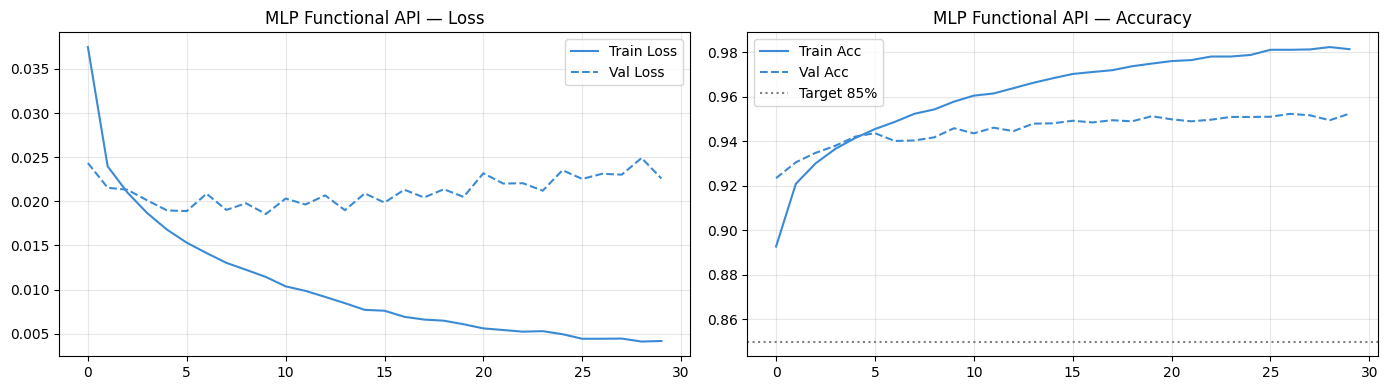

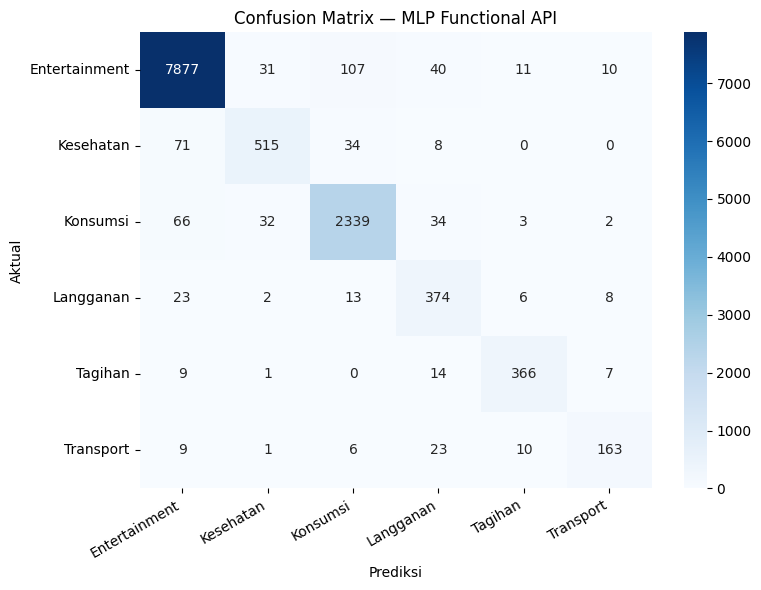

In [15]:
# ── Muat model terbaik (Functional API) ───────────────────────────────────
mlp_func_loaded = keras.models.load_model(
    "artifacts/mlp_functional.keras",
    custom_objects={"ResidualBlock": ResidualBlock, "FocalLoss": FocalLoss}
)

X_test_f32 = X_test_emb.astype(np.float32)

y_pred_func = np.argmax(mlp_func_loaded.predict(X_test_f32, verbose=0), axis=1)
acc_func    = accuracy_score(y_test, y_pred_func)

print("=" * 60)
print(f"Test Accuracy — Functional API : {acc_func:.4f}  ({'✅' if acc_func>=0.85 else '⚠️ '})")
print("=" * 60)

print("\n[Functional API]")
print(classification_report(y_test, y_pred_func, target_names=le.classes_, digits=4))

# ── Plot loss & accuracy ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_func["loss"],     label="Train Loss", color="#3B8BD4")
axes[0].plot(history_func["val_loss"], label="Val Loss",   color="#3B8BD4", ls="--")
axes[0].set_title("MLP Functional API — Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_func["accuracy"],     label="Train Acc", color="#3B8BD4")
axes[1].plot(history_func["val_accuracy"], label="Val Acc",   color="#3B8BD4", ls="--")
axes[1].axhline(0.85, color="gray", ls=":", label="Target 85%")
axes[1].set_title("MLP Functional API — Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ── Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_func)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title("Confusion Matrix — MLP Functional API")
ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## Cell 13 — Inference MLP

In [16]:
# Cell 13 — Inference MLP Functional API + IndoBERT
def predict_mlp(teks_input, top_k=3, model=mlp_func_loaded):
    if isinstance(teks_input, str):
        teks_input = [teks_input]

    teks_bersih = [preprocess(t) for t in teks_input]  # ← pakai fungsi Cell 3

    # Ekstrak BERT embedding
    embeddings = extract_bert_features(teks_bersih)     # ← fungsi dari Cell 5
    X = embeddings.astype(np.float32)

    proba = model.predict(X, verbose=0)
    preds = np.argmax(proba, axis=1)

    results = []
    for i, (pred, prob) in enumerate(zip(preds, proba)):
        label   = le.inverse_transform([pred])[0]
        top_idx = prob.argsort()[::-1][:top_k]
        top_lbl = [f"{le.inverse_transform([j])[0]} ({prob[j]*100:.1f}%)" for j in top_idx]
        results.append({
            "teks"         : teks_input[i],
            "prediksi"     : label,
            "confidence"   : f"{prob[pred]*100:.1f}%",
            f"top_{top_k}" : " | ".join(top_lbl)
        })
    return pd.DataFrame(results)


contoh = [
    "nonton bioskop XXI",
    "cek tensi di klinik",
    "makan nasi goreng di restoran",
    "listrik rumah bulan ini",
    "naik taksi online ke kantor",
    "netflix premium",
    "berobat ke dokter gigi",
    "top up saldo transportasi umum",
    "makan bakso di pinggir jalan",
    "beli pulsa prabayar",
    "konser musik jazz malam ini"
]

print("🔮 Inference MLP Functional API:")
print(predict_mlp(contoh, model=mlp_func_loaded)[["teks", "prediksi", "confidence"]].to_string(index=False))


🔮 Inference MLP Functional API:
  [11/11]
                          teks      prediksi confidence
            nonton bioskop XXI Entertainment      99.3%
           cek tensi di klinik Entertainment      56.1%
 makan nasi goreng di restoran      Konsumsi      98.0%
       listrik rumah bulan ini       Tagihan      98.4%
   naik taksi online ke kantor     Transport     100.0%
               netflix premium     Langganan      92.1%
        berobat ke dokter gigi     Kesehatan      54.1%
top up saldo transportasi umum     Transport      76.4%
  makan bakso di pinggir jalan      Konsumsi      99.3%
           beli pulsa prabayar       Tagihan     100.0%
   konser musik jazz malam ini Entertainment      72.3%


## Cell 19 — Simpan Semua Artifacts

In [17]:
# ─────────────────────────────────────────────────────────────
# Cell 19 — Simpan Artifacts: Functional API, Label Encoder, IndoBERT
# ─────────────────────────────────────────────────────────────
import os
import pickle
import json

os.makedirs("artifacts", exist_ok=True)

# 1. MLP Functional API
# Sudah tersimpan otomatis di artifacts/mlp_functional.keras
# dari best-checkpoint saat training (Cell 9)
print("✅ MLP Functional API: artifacts/mlp_functional.keras (sudah ada dari training)")

# 2. Simpan LabelEncoder
with open("artifacts/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("✅ LabelEncoder disimpan: artifacts/label_encoder.pkl")

# 3. Simpan Config JSON
model_config = {
    "n_classes": N_CLASSES,
    "classes": le.classes_.tolist(),
    "bert_input_dim": int(INPUT_DIM),
    "test_acc_func_api": float(acc_func),
}
with open("artifacts/model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)
print("✅ Config disimpan: artifacts/model_config.json")
print(f"   → Kelas: {model_config['classes']}")
print(f"   → Test Accuracy: {model_config['test_acc_func_api']:.4f}")

# 4. PALING PENTING untuk FastAPI
# Simpan IndoBERT Tokenizer dan Model ke folder lokal
print("\n⏳ Menyimpan Tokenizer dan Model IndoBERT lokal...")
tokenizer_bert.save_pretrained("artifacts/indobert_tokenizer")
bert_model.save_pretrained("artifacts/indobert_model")
print("✅ IndoBERT Tokenizer disimpan: artifacts/indobert_tokenizer/")
print("✅ IndoBERT Model disimpan:     artifacts/indobert_model/")

# 5. Tampilkan isi folder artifacts beserta ukuran file
print("\n📁 Isi folder artifacts:")
for root, dirs, files in os.walk("artifacts"):
    for fname in files:
        filepath = os.path.join(root, fname)
        size = os.path.getsize(filepath) / 1024  # KB
        rel_path = os.path.relpath(filepath, "artifacts")
        print(f"   {rel_path:<45s} {size:>8.1f} KB")

# 6. Ringkasan performa
print("\n📊 Ringkasan Performa:")
print(f"   MLP Functional API : {acc_func*100:.2f}% {'✅' if acc_func >= 0.85 else '❌'}")
print(f"   Target             : 85%")

✅ MLP Functional API: artifacts/mlp_functional.keras (sudah ada dari training)
✅ LabelEncoder disimpan: artifacts/label_encoder.pkl
✅ Config disimpan: artifacts/model_config.json
   → Kelas: ['Entertainment', 'Kesehatan', 'Konsumsi', 'Langganan', 'Tagihan', 'Transport']
   → Test Accuracy: 0.9524

⏳ Menyimpan Tokenizer dan Model IndoBERT lokal...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ IndoBERT Tokenizer disimpan: artifacts/indobert_tokenizer/
✅ IndoBERT Model disimpan:     artifacts/indobert_model/

📁 Isi folder artifacts:
   label_encoder.pkl                                  0.3 KB
   model_config.json                                  0.2 KB
   mlp_functional.keras                            6247.9 KB
   indobert_model/config.json                         1.3 KB
   indobert_model/model.safetensors              486120.8 KB
   indobert_tokenizer/tokenizer_config.json           0.3 KB
   indobert_tokenizer/tokenizer.json                692.7 KB

📊 Ringkasan Performa:
   MLP Functional API : 95.24% ✅
   Target             : 85%


## Cell 20 — Download Artifacts (Google Colab)

In [18]:
# ─────────────────────────────────────────────────────────────
# Cell 20 — Download Artifacts (Google Colab)
# ─────────────────────────────────────────────────────────────
import shutil

# Zip folder artifacts (berisi model, tokenizer, label encoder, config)
shutil.make_archive("artifacts_capstone", "zip", "artifacts")
print("✅ artifacts_capstone.zip siap")

# Zip TensorBoard logs (opsional, untuk analisis training)
shutil.make_archive("tensorboard_logs", "zip", LOG_ROOT)
print("✅ tensorboard_logs.zip siap")

# Download otomatis (hanya berjalan di Google Colab)
try:
    from google.colab import files
    print("\n⏳ Memulai download artifacts_capstone.zip (~450 MB)...")
    files.download("artifacts_capstone.zip")
    print("⏳ Memulai download tensorboard_logs.zip...")
    files.download("tensorboard_logs.zip")
except ImportError:
    print("\nℹ️  Bukan environment Colab.")
    print("   File tersimpan lokal di:")
    print("   → artifacts_capstone.zip")
    print("   → tensorboard_logs.zip")

✅ artifacts_capstone.zip siap
✅ tensorboard_logs.zip siap

⏳ Memulai download artifacts_capstone.zip (~450 MB)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⏳ Memulai download tensorboard_logs.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cell DS A/B Testing


In [19]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    log_loss, f1_score
)
from sklearn.preprocessing import label_binarize
import time

LR_C         = 1.0          # inverse regularization strength
LR_MAX_ITER  = 1000
LR_SOLVER    = "lbfgs"      # cocok untuk multiclass + embedding dense
LR_MULTI     = "multinomial"
RANDOM_STATE = 42
MODEL_LABEL  = "Logistic-Regression"

print("=" * 60)
print("BASELINE — Logistic Regression (IndoBERT Embedding)")
print("=" * 60)

print(f"\nInput shape  : train={X_train_emb.shape}, test={X_test_emb.shape}")
print(f"Solver       : {LR_SOLVER} | C={LR_C} | max_iter={LR_MAX_ITER}")
print(f"\nTraining...")

t0 = time.time()
lr_model = LogisticRegression(
    C=LR_C,
    max_iter=LR_MAX_ITER,
    solver=LR_SOLVER,
    multi_class=LR_MULTI,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)
lr_model.fit(X_train_emb.astype(np.float32), y_train)
elapsed = time.time() - t0
print(f"Selesai dalam {elapsed:.1f}s")

# ── PREDIKSI
y_pred_lr   = lr_model.predict(X_test_emb.astype(np.float32))
y_prob_lr   = lr_model.predict_proba(X_test_emb.astype(np.float32))

acc_lr      = accuracy_score(y_test, y_pred_lr)
loss_lr     = log_loss(y_test, y_prob_lr)

print(f"\nAccuracy : {acc_lr:.4f}")
print(f"Log-loss : {loss_lr:.4f}")
print(f"\n[{MODEL_LABEL}]")
print(classification_report(y_test, y_pred_lr))

history_lr = {
    "loss"         : [loss_lr],
    "val_loss"     : [loss_lr],
    "accuracy"     : [acc_lr],
    "val_accuracy" : [acc_lr],
}

# ── METRICS LOGGER (format sama dengan MetricsLogger MLP)
print(f"\n[{MODEL_LABEL}] Train Summary")
print(f"  val_accuracy : {acc_lr:.4f}")
print(f"  val_loss     : {loss_lr:.4f}")
print(f"\nBest val_acc ({MODEL_LABEL}): {acc_lr:.4f}")

# ── SIMPAN PREDIKSI untuk A/B Testing
pred_baseline     = y_pred_lr
prob_baseline     = y_prob_lr
acc_baseline      = acc_lr
history_baseline  = history_lr

print("\n" + "=" * 60)
print("Variabel tersimpan:")
print("  pred_baseline  -> array prediksi label")
print("  prob_baseline  -> array probabilitas per kelas")
print("  acc_baseline   -> accuracy score")
print("  history_baseline -> dict history (format sama dengan MLP)")
print("=" * 60)

BASELINE — Logistic Regression (IndoBERT Embedding)

Input shape  : train=(48860, 768), test=(12215, 768)
Solver       : lbfgs | C=1.0 | max_iter=1000

Training...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Selesai dalam 68.8s

Accuracy : 0.9293
Log-loss : 0.2173

[Logistic-Regression]
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      8076
           1       0.78      0.67      0.72       628
           2       0.92      0.92      0.92      2476
           3       0.75      0.81      0.78       426
           4       0.88      0.88      0.88       397
           5       0.84      0.76      0.80       212

    accuracy                           0.93     12215
   macro avg       0.85      0.83      0.84     12215
weighted avg       0.93      0.93      0.93     12215


[Logistic-Regression] Train Summary
  val_accuracy : 0.9293
  val_loss     : 0.2173

Best val_acc (Logistic-Regression): 0.9293

Variabel tersimpan:
  pred_baseline  -> array prediksi label
  prob_baseline  -> array probabilitas per kelas
  acc_baseline   -> accuracy score
  history_baseline -> dict history (format sama dengan MLP)


In [20]:
import sys
import io
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')
else:
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8') if hasattr(sys.stdout, 'buffer') else sys.stdout

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import accuracy_score, classification_report, f1_score

ALPHA = 0.05

pred_a = pred_baseline   # Variant A = Logistic Regression
pred_b = y_pred_func     # Variant B = MLP Functional API
y_arr = np.array(y_test)

# Mapping angka -> nama kelas (sesuaikan kalau urutan berbeda)
LABEL_NAMES = ["Entertainment", "Kesehatan", "Konsumsi", "Langganan", "Tagihan", "Transport"]

# ─────────────────────────────────────────────────────────────────────────────
# ACCURACY
# ─────────────────────────────────────────────────────────────────────────────
acc_a = accuracy_score(y_arr, pred_a)
acc_b = accuracy_score(y_arr, pred_b)

print("=" * 60)
print("HASIL A/B TESTING")
print("Variant A : Logistic Regression (Baseline)")
print("Variant B : MLP Functional API  (Model Utama)")
print("=" * 60)

print("\nClassification Report - Variant A (Logistic Regression):")
print(classification_report(y_arr, pred_a, target_names=LABEL_NAMES))

print("Classification Report - Variant B (MLP Functional API):")
print(classification_report(y_arr, pred_b, target_names=LABEL_NAMES))

# ─────────────────────────────────────────────────────────────────────────────
# STATISTICAL TESTING
# ─────────────────────────────────────────────────────────────────────────────
correct_a = (pred_a == y_arr).astype(int)
correct_b = (pred_b == y_arr).astype(int)
n         = len(y_arr)

# -- Z-Test for Proportions --
p_pool  = (correct_a.sum() + correct_b.sum()) / (2 * n)
se      = np.sqrt(p_pool * (1 - p_pool) * (2 / n))
z_stat  = (acc_b - acc_a) / se       # positif = B (MLP) lebih baik
p_val_z = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("[1] Z-Test for Proportions (Accuracy)")
print(f"    Accuracy A (Logistic Regression) : {acc_a:.4f}")
print(f"    Accuracy B (MLP Functional API)  : {acc_b:.4f}")
print(f"    Selisih (B - A)                  : {acc_b - acc_a:+.4f}")
print(f"    Z-statistic                      : {z_stat:.4f}")
print(f"    P-value (two-tailed)             : {p_val_z:.6f}")

# -- McNemar's Test --
both_correct = ((correct_a == 1) & (correct_b == 1)).sum()
a_only       = ((correct_a == 1) & (correct_b == 0)).sum()
b_only       = ((correct_a == 0) & (correct_b == 1)).sum()
both_wrong   = ((correct_a == 0) & (correct_b == 0)).sum()

table = np.array([[both_correct, a_only],
                  [b_only,       both_wrong]])

mcn = mcnemar(table, exact=False, correction=True)

print("\n[2] McNemar's Test (Per-sample Paired Comparison)")
print(f"    Keduanya benar     : {both_correct:,}")
print(f"    Hanya A benar      : {a_only:,}")
print(f"    Hanya B benar      : {b_only:,}")
print(f"    Keduanya salah     : {both_wrong:,}")
print(f"    Chi-square stat    : {mcn.statistic:.4f}")
print(f"    P-value            : {mcn.pvalue:.6f}")

# -- Kesimpulan --
print("\n" + "-" * 60)
print("KESIMPULAN")
print("-" * 60)
print(f"Significance level (alpha) = {ALPHA}")

if p_val_z < ALPHA:
    winner_z = "B (MLP Functional API)" if acc_b > acc_a else "A (Logistic Regression)"
    print(f"\nZ-Test: Perbedaan SIGNIFIKAN (p={p_val_z:.4f} < {ALPHA})")
    print(f"   -> Variant {winner_z} secara statistik lebih baik.")
else:
    print(f"\nZ-Test: Perbedaan TIDAK signifikan (p={p_val_z:.4f} >= {ALPHA})")
    print(f"   -> Kedua variant tidak berbeda secara statistik.")

if mcn.pvalue < ALPHA:
    winner_mcn = "B (MLP Functional API)" if b_only > a_only else "A (Logistic Regression)"
    print(f"\nMcNemar: Perbedaan SIGNIFIKAN (p={mcn.pvalue:.4f} < {ALPHA})")
    print(f"   -> Variant {winner_mcn} lebih sering benar pada sample yang sama.")
else:
    print(f"\nMcNemar: Perbedaan TIDAK signifikan (p={mcn.pvalue:.4f} >= {ALPHA})")
    print(f"   -> Pola prediksi keduanya tidak berbeda secara bermakna.")

# -- Per-class F1 --
print("\n" + "-" * 60)
print("Per-class F1 Score Comparison:")
print("-" * 60)
labels_sorted = list(range(len(LABEL_NAMES)))
f1_a = f1_score(y_arr, pred_a, average=None, labels=labels_sorted)
f1_b = f1_score(y_arr, pred_b, average=None, labels=labels_sorted)
f1_df = pd.DataFrame({
    "Label"                        : LABEL_NAMES,
    "F1 - Variant A (LR Baseline)" : f1_a.round(4),
    "F1 - Variant B (MLP Func)"    : f1_b.round(4),
    "Selisih (B-A)"                : (f1_b - f1_a).round(4)
})
print(f1_df.to_string(index=False))
print("=" * 60)

HASIL A/B TESTING
Variant A : Logistic Regression (Baseline)
Variant B : MLP Functional API  (Model Utama)

Classification Report - Variant A (Logistic Regression):
               precision    recall  f1-score   support

Entertainment       0.96      0.97      0.96      8076
    Kesehatan       0.78      0.67      0.72       628
     Konsumsi       0.92      0.92      0.92      2476
    Langganan       0.75      0.81      0.78       426
      Tagihan       0.88      0.88      0.88       397
    Transport       0.84      0.76      0.80       212

     accuracy                           0.93     12215
    macro avg       0.85      0.83      0.84     12215
 weighted avg       0.93      0.93      0.93     12215

Classification Report - Variant B (MLP Functional API):
               precision    recall  f1-score   support

Entertainment       0.98      0.98      0.98      8076
    Kesehatan       0.88      0.82      0.85       628
     Konsumsi       0.94      0.94      0.94      2476
    L